In [1]:
from sim_tools import run_simulation, SimulationParameters

In [4]:
# Run a single simulation with default parameters
result = run_simulation()
if result:
    print("Simulation succeeded.")
    print(result)
else:
    print("Simulation failed or returned no results.")

Simulation succeeded.
runId='e184c67f-77e0-4ae1-af93-e3c2544f7fc8' duration=250.02154541015625 didSucceed=False timeScale=1.0 antCount=110 torusPositions=[Point(x=-9.878568649291992, y=6.447658061981201), Point(x=-9.878568649291992, y=6.447658061981201), Point(x=-9.878568649291992, y=6.447658061981201), Point(x=-9.878568649291992, y=6.447658061981201), Point(x=-9.878568649291992, y=6.447658061981201), Point(x=-9.878568649291992, y=6.447658061981201), Point(x=-9.878568649291992, y=6.447658061981201), Point(x=-9.878568649291992, y=6.447658061981201), Point(x=-9.878568649291992, y=6.447658061981201), Point(x=-9.878568649291992, y=6.447658061981201), Point(x=-9.878568649291992, y=6.447658061981201), Point(x=-9.878568649291992, y=6.447658061981201), Point(x=-9.878568649291992, y=6.447658061981201), Point(x=-9.878568649291992, y=6.447658061981201), Point(x=-9.878568649291992, y=6.447658061981201), Point(x=-9.878568649291992, y=6.447658061981201), Point(x=-9.878568649291992, y=6.4476580619812

In [ ]:
# Run a batch of simulations in parallel
# param_list = [sim_tools.SimulationParameters(antCount=ac) for ac in range(50, 52)]
# batch_results = sim_tools.run_simulations_batch(param_list)

# for i, res in enumerate(batch_results):
#     if res:
#         print(f"Run {i+1} (antCount={param_list[i].antCount}): Success, duration={res.duration}")
#     else:
#         print(f"Run {i+1} (antCount={param_list[i].antCount}): Failed")

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import random
from tqdm import tqdm

# take  alot of random numbers from 3 to 20

infromed_times = [random.randint(3, 20) for _ in range(300)]

batch_results = [(run_simulation(SimulationParameters(infromedTime=it)), it) 
                 for it in tqdm(infromed_times)]

print("Batch simulation results:")
for i, (res, it) in enumerate(batch_results):
    if res:
        print(f"Run {i+1} (infromedTime={it}): Success, duration={res.duration},  \
              success={res.didSucceed}")
    else:
        print(f"Run {i+1} (infromedTime={it}): Failed")

# Plot torus positions from the first successful batch result


100%|██████████| 300/300 [34:06<00:00,  6.82s/it]

Batch simulation results:
Run 1 (infromedTime=12): Success, duration=250.00009155273438,                success=False
Run 2 (infromedTime=8): Success, duration=250.04238891601562,                success=False
Run 3 (infromedTime=11): Success, duration=250.00010681152344,                success=False
Run 4 (infromedTime=20): Success, duration=119.26795959472656,                success=True
Run 5 (infromedTime=13): Success, duration=250.02377319335938,                success=False
Run 6 (infromedTime=16): Success, duration=250.00709533691406,                success=False
Run 7 (infromedTime=19): Success, duration=250.03201293945312,                success=False
Run 8 (infromedTime=4): Success, duration=250.03895568847656,                success=False
Run 9 (infromedTime=19): Success, duration=250.03123474121094,                success=False
Run 10 (infromedTime=8): Success, duration=250.03012084960938,                success=False
Run 11 (infromedTime=19): Success, duration=250.058425903

Data for plotting (infromedTime, duration): [(20, 119.26795959472656), (4, 208.3781280517578), (13, 167.3582763671875), (5, 139.92752075195312), (3, 179.5365753173828), (17, 176.30783081054688), (19, 237.1523895263672), (8, 224.9234619140625), (11, 174.87081909179688), (15, 198.31210327148438), (12, 163.1790008544922)]
Success rate: 3.67%


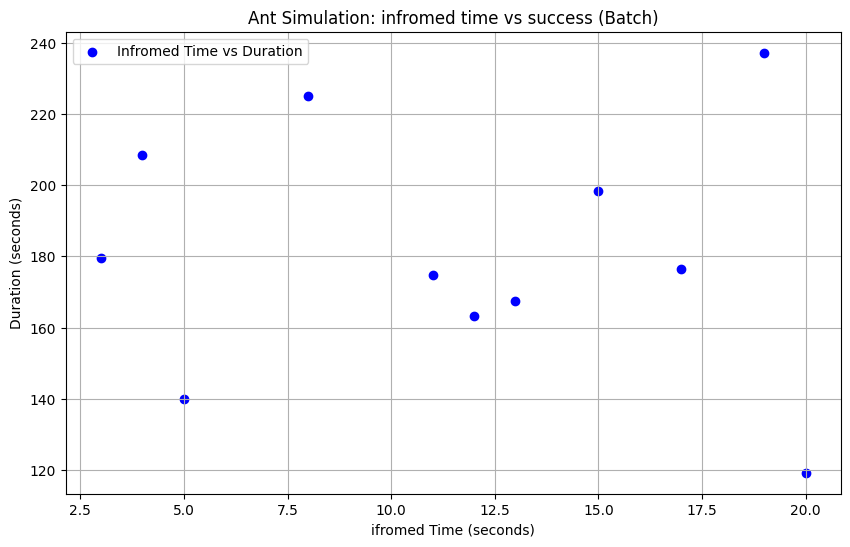

In [7]:
data = [(it, res.duration) for res, it in batch_results if res and res.didSucceed]
print("Data for plotting (infromedTime, duration):", data)
it, durations = zip(*data) if data else ([], [])

# sucess rate
success_rate = sum(1 for res, _ in batch_results if res and res.didSucceed) / len(batch_results)
print(f"Success rate: {success_rate:.2%}")

# plotting the results
plt.figure(figsize=(10, 6))
plt.scatter(it, durations, color='blue', label='Infromed Time vs Duration', marker='o')
            
        
plt.title("Ant Simulation: infromed time vs success (Batch)")
plt.xlabel("ifromed Time (seconds)")
plt.ylabel("Duration (seconds)")
plt.legend()
plt.grid(True)
plt.show()

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import random
from tqdm import tqdm

use_pher = [bool(random.getrandbits(1)) for _ in range(40)]

batch_results = [(run_simulation(SimulationParameters(usePheromoneSteering=pher)), pher) 
                 for pher in tqdm(use_pher)]

100%|██████████| 40/40 [05:05<00:00,  7.64s/it]


In [8]:
batch_results2 = [(run_simulation(SimulationParameters(usePheromoneSteering=pher)), pher) 
                 for pher in tqdm(use_pher)]

  2%|▎         | 1/40 [00:14<09:35, 14.75s/it]


KeyboardInterrupt: 

In [10]:
data = [(res.duration, used_pher) for res,used_pher  in batch_results if res and res.didSucceed]
plt.figure(figsize=(10, 6))


print(np.average([res.duration for res, used_pher in batch_results if res and res.didSucceed and used_pher ]))
print(np.average([res.duration for res, used_pher in batch_results if res and res.didSucceed and not used_pher ]))

167.34454345703125
215.76556396484375


<Figure size 1000x600 with 0 Axes>